# A3: Transformer is All You Need

---

## Phase 0: Setup

In [32]:
! pip install requests torch tokenizers matplotlib numpy

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import requests
import os

import re

from tokenizers import Tokenizer, decoders
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# Create figures directory
os.makedirs("figures", exist_ok=True)

Using device: mps


---

## Phase 1: Data Preparation

### 1.1 Load the Tiny Shakespeare Text

In [34]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
raw_text = response.text

print(f"Total characters: {len(raw_text):,}")
print(f"Unique characters: {len(set(raw_text))}")
print(f"\nFirst 200 characters:\n{raw_text[:200]}")

Total characters: 1,115,394
Unique characters: 65

First 200 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


### 1.2 BPE Tokenization

We use a subword-level tokenizer (Byte Pair Encoding) with a vocabulary size of 500. The `Whitespace` pre-tokenizer splits on word boundaries, allowing BPE to allocate most of its merge budget to meaningful subword units. The `end_of_word_suffix` marks the last subword of each word so the decoder knows where to insert spaces.

In [35]:
# Initialize and train BPE tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
tokenizer.decoder = decoders.BPEDecoder(suffix="</w>")

trainer = BpeTrainer(
    vocab_size=500,
    special_tokens=["[UNK]", "[PAD]", "[BOS]", "[EOS]"],
    end_of_word_suffix="</w>"
)
tokenizer.train_from_iterator([raw_text], trainer=trainer)

# Decode helper: BPEDecoder handles subword joining via </w> suffix.
# We additionally fix spacing around punctuation (Whitespace pre-tokenizer
# splits punctuation as separate words, e.g. "Citizen" + ":" -> "Citizen :").
_PUNCT_FIX = re.compile(r" +([.,;:!?\)\]\'\"-])")

def decode_tokens(ids):
    text = tokenizer.decode(ids)
    text = _PUNCT_FIX.sub(r"\1", text)
    return text

# Encode the entire dataset
encoded = tokenizer.encode(raw_text)
data = torch.tensor(encoded.ids, dtype=torch.long)

print(f"Vocabulary size: {tokenizer.get_vocab_size()}")
print(f"Total tokens: {len(data):,}")
print(f"Compression ratio: {len(raw_text)/len(data):.2f} chars/token")

# Verify decode
sample_enc = tokenizer.encode(raw_text[:120])
print(f"\nSample decode: {decode_tokens(sample_enc.ids)[:80]}")
print(f"Sample tokens:  {sample_enc.tokens[:15]}")




Vocabulary size: 500
Total tokens: 485,062
Compression ratio: 2.30 chars/token

Sample decode: First Citizen: Before we proceed any further, hear me speak. All: Speak, speak. 
Sample tokens:  ['F', 'irst</w>', 'C', 'i', 'ti', 'z', 'en</w>', ':</w>', 'B', 'e', 'fore</w>', 'we</w>', 'pro', 'c', 'e']


### 1.3 Train/Validation Split & Sequence Formatting

We split 80/20 on the token stream, then sample fixed-length sequences for next-token prediction. Each input sequence is paired with a target that is the same sequence shifted right by one position.

In [36]:
# Hyperparameters
SEQ_LEN = 64       # Context window size
BATCH_SIZE = 64     # Batch size

# 80/20 split
split_idx = int(len(data) * 0.8)
train_data = data[:split_idx]
val_data = data[split_idx:]

print(f"Training tokens:   {len(train_data):,}")
print(f"Validation tokens: {len(val_data):,}")

def get_batch(split):
    """Sample a batch of (input, target) sequences for next-token prediction."""
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - SEQ_LEN, (BATCH_SIZE,))
    x = torch.stack([d[i   : i + SEQ_LEN]     for i in ix])
    y = torch.stack([d[i+1 : i + SEQ_LEN + 1] for i in ix])
    return x.to(device), y.to(device)

# Verify shapes
xb, yb = get_batch("train")
print(f"\nBatch shapes:  X={xb.shape}, Y={yb.shape}")
print(f"Sample input:  {xb[0, :10].tolist()}")
print(f"Sample target: {yb[0, :10].tolist()}")
print("(Target is input shifted right by 1 position)")

Training tokens:   388,049
Validation tokens: 97,013

Batch shapes:  X=torch.Size([64, 64]), Y=torch.Size([64, 64])
Sample input:  [408, 202, 192, 52, 78, 136, 191, 326, 366, 196]
Sample target: [202, 192, 52, 78, 136, 191, 326, 366, 196, 55]
(Target is input shifted right by 1 position)


---

## Phase 2: Transformer Model Implementation

### 2.1 Sinusoidal Positional Encoding

In [37]:
class SinusoidalPositionalEncoding(nn.Module):
    """Classic sinusoidal positional encoding from 'Attention Is All You Need'."""
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

# Quick test
_pe = SinusoidalPositionalEncoding(128)
_x = torch.zeros(2, 64, 128)
assert _pe(_x).shape == (2, 64, 128)
print("[OK] SinusoidalPositionalEncoding")

[OK] SinusoidalPositionalEncoding


### 2.2 RMSNorm

In [38]:
class RMSNorm(nn.Module):
    """Root Mean Square Layer Normalization."""
    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return x / rms * self.weight

# Quick test
_norm = RMSNorm(128)
_x = torch.randn(2, 64, 128)
assert _norm(_x).shape == (2, 64, 128)
print("[OK] RMSNorm")

[OK] RMSNorm


### 2.3 Multi-Head Self-Attention

In [39]:
class MultiHeadSelfAttention(nn.Module):
    """Multi-head self-attention with causal mask."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.attn_weights = None  # Stored for visualization

    def forward(self, x):
        B, T, C = x.shape
        q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        # Scaled dot-product attention with causal mask
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)
        causal_mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(causal_mask, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        self.attn_weights = attn.detach()
        attn = self.dropout(attn)

        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.W_o(out)

# Quick test
_mhsa = MultiHeadSelfAttention(128, 4)
_x = torch.randn(2, 64, 128)
assert _mhsa(_x).shape == (2, 64, 128)
print(f"[OK] MultiHeadSelfAttention | attn shape: {_mhsa.attn_weights.shape}")

[OK] MultiHeadSelfAttention | attn shape: torch.Size([2, 4, 64, 64])


### 2.4 Feed-Forward Network

In [40]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network with GELU activation."""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

# Quick test
_ff = FeedForward(128, 512)
_x = torch.randn(2, 64, 128)
assert _ff(_x).shape == (2, 64, 128)
print("[OK] FeedForward")

[OK] FeedForward


### 2.5 Transformer Block

In [41]:
class TransformerBlock(nn.Module):
    """Pre-norm Transformer block: RMSNorm → Attn → Residual → RMSNorm → FFN → Residual."""
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.norm2 = RMSNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x

# Quick test
_block = TransformerBlock(128, 4, 512)
_x = torch.randn(2, 64, 128)
assert _block(_x).shape == (2, 64, 128)
print("[OK] TransformerBlock")

[OK] TransformerBlock


### 2.6 Full TinyTransformer Model

In [42]:
class TinyTransformer(nn.Module):
    """Tiny Transformer language model for next-token prediction."""
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, seq_len, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len=seq_len)
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm_f = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)
        self.lm_head.weight = self.token_emb.weight  # Weight tying
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x):
        x = self.token_emb(x)
        x = self.pos_enc(x)
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm_f(x)
        return self.lm_head(x)

    def get_attention_weights(self):
        return [block.attn.attn_weights for block in self.blocks]

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.seq_len:]
            logits = self(idx_cond)[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            probs = F.softmax(logits, dim=-1)
            idx = torch.cat([idx, torch.multinomial(probs, num_samples=1)], dim=1)
        return idx

In [43]:
# Model hyperparameters
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 2
D_FF = 512
VOCAB_SIZE = tokenizer.get_vocab_size()
DROPOUT = 0.1

model = TinyTransformer(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, n_heads=N_HEADS,
    n_layers=N_LAYERS, d_ff=D_FF, seq_len=SEQ_LEN, dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")
print(f"Architecture: d_model={D_MODEL}, n_heads={N_HEADS}, n_layers={N_LAYERS}, d_ff={D_FF}")
print(f"              vocab_size={VOCAB_SIZE}, seq_len={SEQ_LEN}, dropout={DROPOUT}")

# Verify forward pass
xb, yb = get_batch("train")
logits = model(xb)
print(f"\nForward pass: input {xb.shape} → logits {logits.shape}")
assert logits.shape == (BATCH_SIZE, SEQ_LEN, VOCAB_SIZE)
print("[OK] TinyTransformer")

Model parameters: 460,660
Architecture: d_model=128, n_heads=4, n_layers=2, d_ff=512
              vocab_size=500, seq_len=64, dropout=0.1

Forward pass: input torch.Size([64, 64]) → logits torch.Size([64, 64, 500])
[OK] TinyTransformer


---

## Phase 3: Training

### 3.1 Training Setup

In [44]:
MAX_STEPS = 10000
EVAL_INTERVAL = 250
EVAL_STEPS = 50
LR = 3e-4
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 200

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def get_lr(step):
    if step < WARMUP_STEPS:
        return LR * step / WARMUP_STEPS
    decay_ratio = (step - WARMUP_STEPS) / (MAX_STEPS - WARMUP_STEPS)
    return LR * 0.5 * (1.0 + math.cos(math.pi * decay_ratio))

print(f"Training config: max_steps={MAX_STEPS}, lr={LR}, warmup={WARMUP_STEPS}")
print(f"  eval_interval={EVAL_INTERVAL}, eval_steps={EVAL_STEPS}, weight_decay={WEIGHT_DECAY}")

Training config: max_steps=10000, lr=0.0003, warmup=200
  eval_interval=250, eval_steps=50, weight_decay=0.01


### 3.2 Training Loop

In [45]:
@torch.no_grad()
def estimate_loss():
    model.eval()
    losses = {}
    for split in ["train", "val"]:
        batch_losses = []
        for _ in range(EVAL_STEPS):
            xb, yb = get_batch(split)
            logits = model(xb)
            loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), yb.view(-1))
            batch_losses.append(loss.item())
        losses[split] = np.mean(batch_losses)
    model.train()
    return losses

history = {"step": [], "train_loss": [], "val_loss": [], "val_ppl": [], "lr": []}
attn_snapshots = {}  # For attention evolution visualization

print("Starting training...")
start_time = time.time()
model.train()

for step in range(MAX_STEPS):
    lr = get_lr(step)
    for pg in optimizer.param_groups:
        pg['lr'] = lr

    xb, yb = get_batch("train")
    logits = model(xb)
    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), yb.view(-1))
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if step % EVAL_INTERVAL == 0 or step == MAX_STEPS - 1:
        losses = estimate_loss()
        val_ppl = math.exp(losses["val"])
        elapsed = time.time() - start_time
        print(f"Step {step:5d} | train={losses['train']:.4f} | val={losses['val']:.4f} | "
              f"ppl={val_ppl:.2f} | lr={lr:.2e} | {elapsed:.1f}s")
        history["step"].append(step)
        history["train_loss"].append(losses["train"])
        history["val_loss"].append(losses["val"])
        history["val_ppl"].append(val_ppl)
        history["lr"].append(lr)

    # Save attention snapshots at key steps
    if step in [0, 500, 1000, 2500, MAX_STEPS - 1]:
        model.eval()
        with torch.no_grad():
            xsnap, _ = get_batch("val")
            _ = model(xsnap[:1])
            attn_snapshots[step] = {
                "input_ids": xsnap[0].cpu(),
                "attns": [a[0].cpu() for a in model.get_attention_weights()]
            }
        model.train()

total_time = time.time() - start_time
print(f"\nDone in {total_time:.1f}s | Final val_loss={history['val_loss'][-1]:.4f}, ppl={history['val_ppl'][-1]:.2f}")

Starting training...
Step     0 | train=6.2284 | val=6.2259 | ppl=505.69 | lr=0.00e+00 | 4.0s
Step   250 | train=5.6488 | val=5.6585 | ppl=286.71 | lr=3.00e-04 | 12.1s
Step   500 | train=5.6428 | val=5.6620 | ppl=287.72 | lr=2.99e-04 | 19.9s
Step   750 | train=5.6451 | val=5.6608 | ppl=287.37 | lr=2.98e-04 | 27.8s
Step  1000 | train=5.6455 | val=5.6610 | ppl=287.43 | lr=2.95e-04 | 35.5s
Step  1250 | train=5.6440 | val=5.6594 | ppl=286.96 | lr=2.92e-04 | 43.6s
Step  1500 | train=5.6465 | val=5.6577 | ppl=286.50 | lr=2.87e-04 | 51.8s
Step  1750 | train=5.6331 | val=5.6460 | ppl=283.17 | lr=2.82e-04 | 59.6s
Step  2000 | train=4.9674 | val=5.0001 | ppl=148.43 | lr=2.76e-04 | 67.3s
Step  2250 | train=4.7583 | val=4.7964 | ppl=121.07 | lr=2.69e-04 | 76.0s
Step  2500 | train=4.6544 | val=4.7036 | ppl=110.35 | lr=2.61e-04 | 84.4s
Step  2750 | train=4.5773 | val=4.6333 | ppl=102.86 | lr=2.53e-04 | 91.9s
Step  3000 | train=4.5064 | val=4.5775 | ppl=97.27 | lr=2.44e-04 | 99.8s
Step  3250 | train=

### 3.3 Training Curves

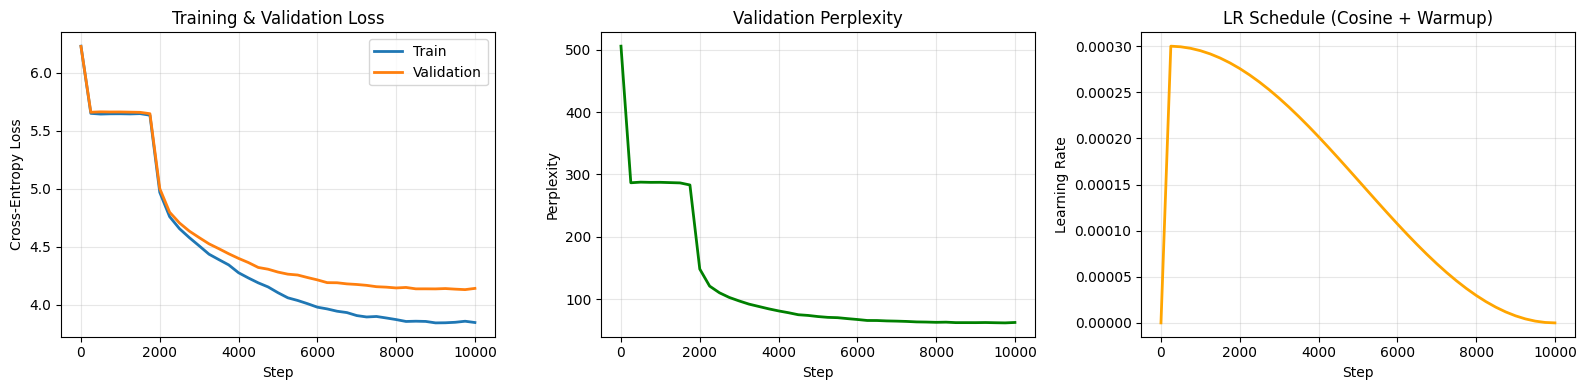

Saved: figures/training_curves.png


In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["step"], history["train_loss"], label="Train", linewidth=2)
axes[0].plot(history["step"], history["val_loss"], label="Validation", linewidth=2)
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Training & Validation Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["step"], history["val_ppl"], color="green", linewidth=2)
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("Validation Perplexity"); axes[1].grid(True, alpha=0.3)

axes[2].plot(history["step"], history["lr"], color="orange", linewidth=2)
axes[2].set_xlabel("Step"); axes[2].set_ylabel("Learning Rate")
axes[2].set_title("LR Schedule (Cosine + Warmup)"); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/training_curves.png")

### 3.4 Sample Text Generation

In [47]:
model.eval()
prompts = ["KING", "To be", "What", "ROMEO"]

print("=" * 60)
print("SAMPLE TEXT GENERATION")
print("=" * 60)

for prompt in prompts:
    input_ids = torch.tensor([tokenizer.encode(prompt).ids], dtype=torch.long, device=device)
    output_ids = model.generate(input_ids, max_new_tokens=80, temperature=0.8, top_k=40)
    text = decode_tokens(output_ids[0].cpu().tolist())
    print(f"\nPrompt: '{prompt}'")
    print(f"Generated: {text[:200]}")
    print("-" * 60)

SAMPLE TEXT GENERATION

Prompt: 'KING'
Generated: KING ADWARD IV: My lord, for I know the ceatiice, And we be the very mar, And knoness song: he, good more are traied the fow a chith in the liskes: And, and not, we shall put me I was not the chose! H
------------------------------------------------------------

Prompt: 'To be'
Generated: To be fire of him, I shall have to seese, And thou in the fazere' s wither sraish a hears with the count. JULIET: Your, as I am to my vose, I' ll my flay of the kings, To be you shall not. DETUS:
------------------------------------------------------------

Prompt: 'What'
Generated: What' s, and no wruress a pree plongn in me, to my brice, And thou remester, And wouled' s in this endess a fot To wugn it, Well this fentleman ceet, I call thou cear me. BRAON
------------------------------------------------------------

Prompt: 'ROMEO'
Generated: ROMEO: And then, I' ll not that set. AdCALINLUS: What be foper, my lord' s wreight. What, my very childen I se

---

## Phase 4: Visualization & Analysis

### 4.1 Attention Heatmaps

We visualize the attention weights from all layers and heads for a sample input to understand what the model has learned to attend to.

In [48]:
model.eval()

# Pick a recognizable prompt for interpretable attention maps
prompt_text = "ROMEO: O, she doth teach the torches to burn bright"
prompt_enc = tokenizer.encode(prompt_text)
prompt_ids = prompt_enc.ids
prompt_tokens = prompt_enc.tokens

# Truncate to SEQ_LEN if needed, pad if too short
if len(prompt_ids) > SEQ_LEN:
    prompt_ids = prompt_ids[:SEQ_LEN]
    prompt_tokens = prompt_tokens[:SEQ_LEN]

input_tensor = torch.tensor([prompt_ids], dtype=torch.long, device=device)

with torch.no_grad():
    _ = model(input_tensor)
    attn_weights = model.get_attention_weights()

print(f"Prompt: {prompt_text}")
print(f"Tokens ({len(prompt_tokens)}): {prompt_tokens}")
print(f"Layers: {len(attn_weights)}, Heads per layer: {attn_weights[0].shape[0]}")

Prompt: ROMEO: O, she doth teach the torches to burn bright
Tokens (25): ['RO', 'M', 'E', 'O</w>', ':</w>', 'O</w>', ',</w>', 'she</w>', 'do', 'th</w>', 't', 'ea', 'ch</w>', 'the</w>', 't', 'or', 'ch', 'es</w>', 'to</w>', 'b', 'ur', 'n</w>', 'b', 'ri', 'ght</w>']
Layers: 2, Heads per layer: 1


#### Attention Heatmaps by Layer and Head

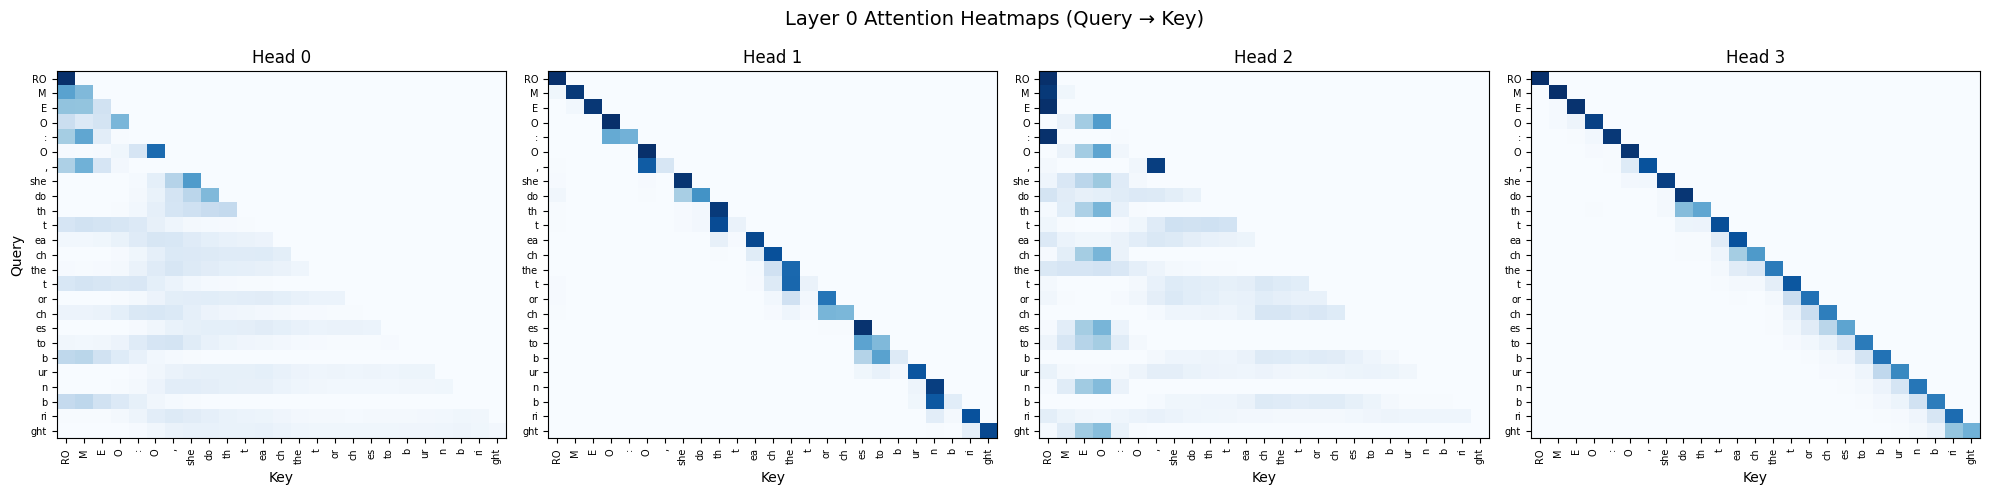

Saved: figures/attention_heatmaps_layer0.png


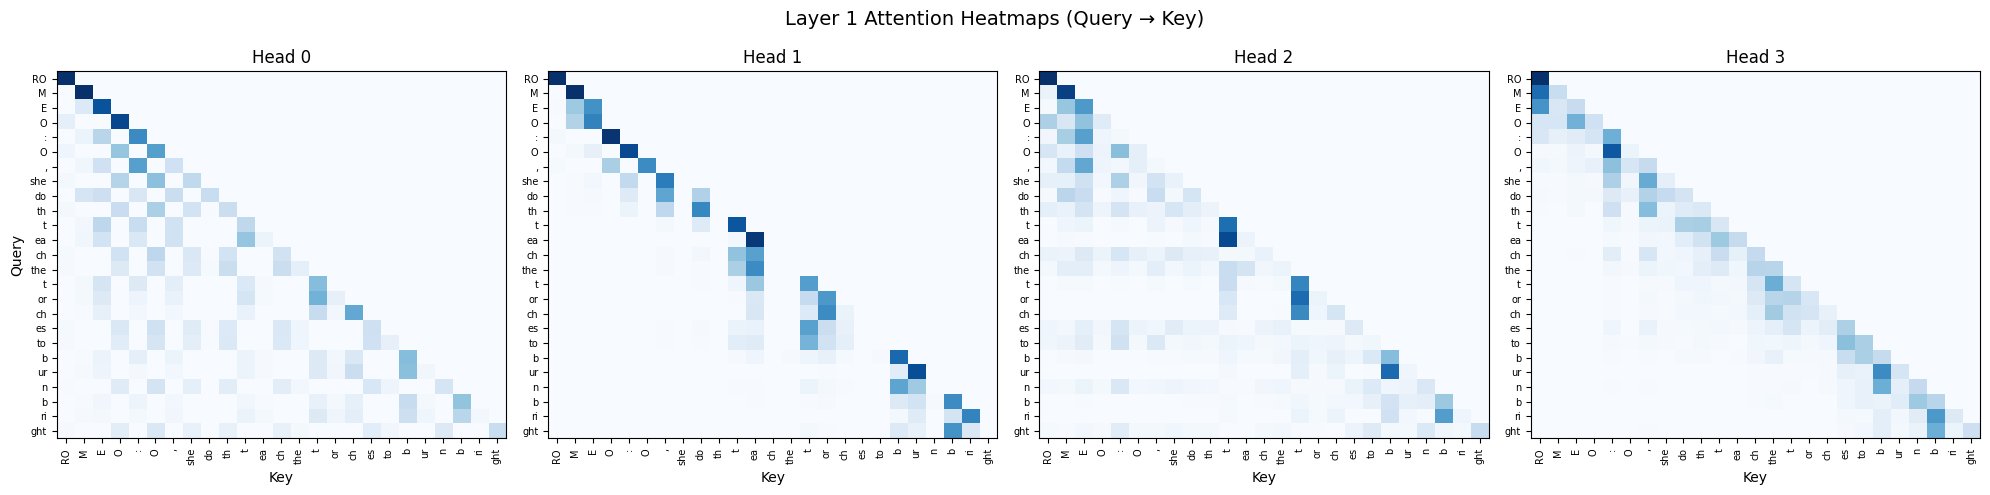

Saved: figures/attention_heatmaps_layer1.png


In [49]:
# Clean token labels for display (remove </w> suffix)
labels = [t.replace("</w>", "") for t in prompt_tokens]
n_tokens = len(labels)

# Plot each layer separately for better readability
for layer_idx in range(N_LAYERS):
    fig, axes = plt.subplots(1, N_HEADS, figsize=(5 * N_HEADS, 5))
    if N_HEADS == 1:
        axes = [axes]
    for head_idx in range(N_HEADS):
        ax = axes[head_idx]
        attn = attn_weights[layer_idx][0, head_idx, :n_tokens, :n_tokens].cpu().numpy()
        im = ax.imshow(attn, cmap="Blues", aspect="auto", vmin=0)
        ax.set_title(f"Head {head_idx}", fontsize=12)
        ax.set_xticks(range(n_tokens))
        ax.set_yticks(range(n_tokens))
        ax.set_xticklabels(labels, rotation=90, fontsize=7)
        ax.set_yticklabels(labels, fontsize=7)
        ax.set_ylabel("Query") if head_idx == 0 else None
        ax.set_xlabel("Key")
    plt.suptitle(f"Layer {layer_idx} Attention Heatmaps (Query → Key)", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"figures/attention_heatmaps_layer{layer_idx}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: figures/attention_heatmaps_layer{layer_idx}.png")

#### Attention Pattern Analysis

We compute summary statistics to characterize each head's attention behavior: how much it attends to the current token (diagonal), to the first token (vertical stripe), and its overall entropy (uniformity vs. sharpness).

In [50]:
print("=" * 70)
print(f"{'Layer':>5} {'Head':>4} {'Diag%':>7} {'First%':>7} {'Entropy':>8}  Pattern")
print("=" * 70)

for layer_idx in range(N_LAYERS):
    for head_idx in range(N_HEADS):
        attn = attn_weights[layer_idx][0, head_idx, :n_tokens, :n_tokens].cpu().numpy()

        # Diagonal attention (local/current token)
        diag_attn = np.mean(np.diag(attn))

        # First-token attention (global anchor)
        first_col_attn = np.mean(attn[:, 0])

        # Entropy (uniformity measure)
        entropy = -np.sum(attn * np.log(attn + 1e-10), axis=-1).mean()

        # Classify pattern
        if diag_attn > 0.3:
            pattern = "LOCAL (attends to current position)"
        elif first_col_attn > 0.3:
            pattern = "GLOBAL (anchors on first token)"
        elif entropy > 2.5:
            pattern = "DIFFUSE (spread attention)"
        else:
            pattern = "MIXED"

        print(f"{layer_idx:>5} {head_idx:>4} {diag_attn:>6.1%} {first_col_attn:>6.1%} {entropy:>8.3f}  {pattern}")

Layer Head   Diag%  First%  Entropy  Pattern
    0    0  18.6%  15.4%    1.836  MIXED
    0    1  69.1%   4.6%    0.444  LOCAL (attends to current position)
    0    2  13.1%  19.4%    1.529  MIXED
    0    3  79.5%   4.1%    0.604  LOCAL (attends to current position)
    1    0  36.5%   4.9%    1.379  LOCAL (attends to current position)
    1    1  35.9%   4.1%    0.742  LOCAL (attends to current position)
    1    2  25.3%   8.1%    1.510  MIXED
    1    3  24.6%  11.1%    1.430  MIXED


#### Qualitative Token-Level Analysis

Beyond aggregate statistics, we examine specific token-level attention patterns to understand what relationships the model has learned.

In [51]:
# Qualitative: Which tokens does ":" attend to? (Should attend back to character name)
colon_indices = [i for i, t in enumerate(prompt_tokens) if ":" in t]
print("Token-level attention analysis:")
print("=" * 60)
for ci in colon_indices:
    print(f"\nToken '{labels[ci]}' at position {ci} attends to:")
    for layer_idx in range(N_LAYERS):
        attn_row = attn_weights[layer_idx][0, :, ci, :ci+1].cpu().numpy()  # all heads
        for head_idx in range(N_HEADS):
            top_k = min(3, ci+1)
            top_indices = attn_row[head_idx].argsort()[-top_k:][::-1]
            top_str = ", ".join([f"'{labels[j]}' ({attn_row[head_idx][j]:.2f})" for j in top_indices])
            print(f"  L{layer_idx}H{head_idx}: {top_str}")

# Check if any head learns to attend from punctuation back to the preceding word
print(f"\nDoes any head connect ':' back to 'ROMEO'?")
romeo_idx = next((i for i, t in enumerate(labels) if "ROMEO" in t), None)
if romeo_idx is not None and colon_indices:
    ci = colon_indices[0]
    for li in range(N_LAYERS):
        for hi in range(N_HEADS):
            w = attn_weights[li][0, hi, ci, romeo_idx].item()
            print(f"  L{li}H{hi}: ':' -> 'ROMEO' attention = {w:.3f}")

Token-level attention analysis:

Token ':' at position 4 attends to:
  L0H0: 'M' (0.53), 'RO' (0.36), 'E' (0.10)
  L0H1: 'O' (0.52), ':' (0.48), 'E' (0.00)
  L0H2: 'RO' (0.99), ':' (0.00), 'M' (0.00)
  L0H3: ':' (0.97), 'O' (0.03), 'E' (0.00)
  L1H0: ':' (0.65), 'E' (0.29), 'M' (0.06)
  L1H1: 'O' (0.98), 'RO' (0.02), 'M' (0.00)
  L1H2: 'E' (0.56), 'M' (0.34), 'O' (0.04)
  L1H3: ':' (0.49), 'O' (0.17), 'RO' (0.15)

Does any head connect ':' back to 'ROMEO'?


### 4.2 Attention Evolution Over Training

We saved attention snapshots at key training steps and compare two contrasting heads: the strongly local "bigram" head (Layer 0 Head 3) vs. a mixed-pattern head (Layer 1 Head 1).

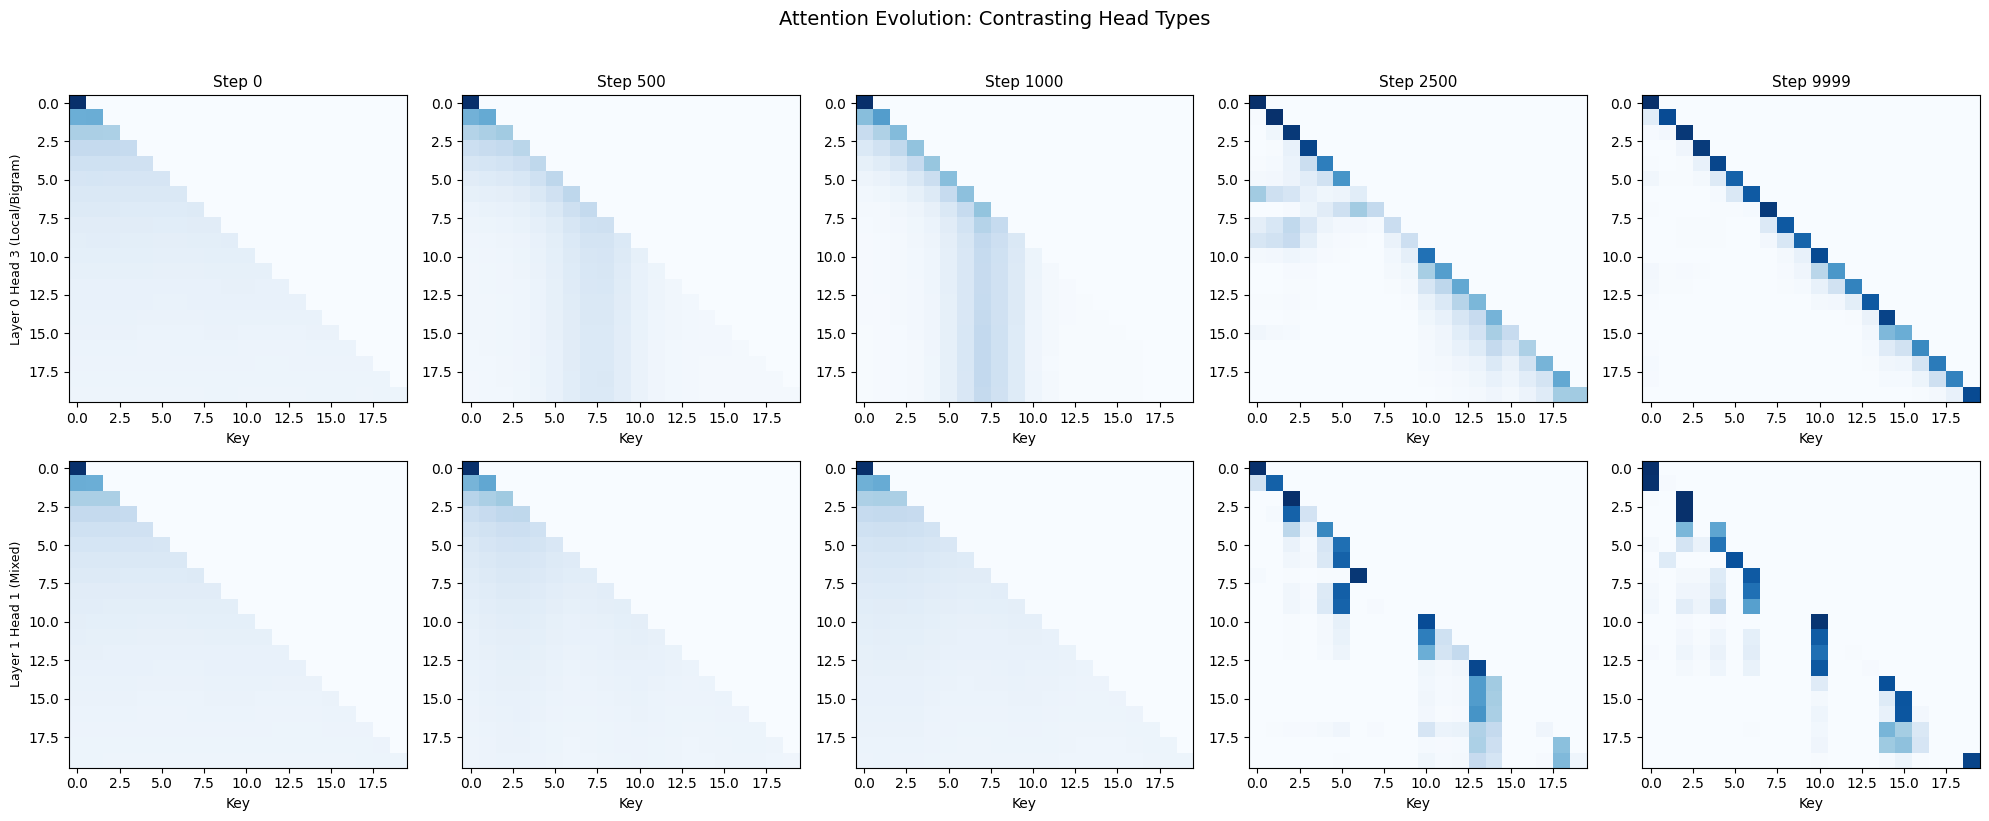

Saved: figures/attention_evolution.png


In [52]:
snapshot_steps = sorted(attn_snapshots.keys())
n_snapshots = len(snapshot_steps)

# Show two contrasting heads: the "bigram" head (L0H3) vs a "mixed" head (L1H1)
head_configs = [
    {"layer": 0, "head": min(3, N_HEADS-1), "label": "Layer 0 Head 3 (Local/Bigram)"},
    {"layer": min(1, N_LAYERS-1), "head": min(1, N_HEADS-1), "label": f"Layer {min(1,N_LAYERS-1)} Head 1 (Mixed)"},
]

fig, axes = plt.subplots(len(head_configs), n_snapshots, figsize=(4 * n_snapshots, 4 * len(head_configs)))
if len(head_configs) == 1:
    axes = axes.reshape(1, -1)

for row, hcfg in enumerate(head_configs):
    for col, step in enumerate(snapshot_steps):
        snap = attn_snapshots[step]
        attn = snap["attns"][hcfg["layer"]][hcfg["head"]].numpy()
        n = min(20, attn.shape[0])
        axes[row][col].imshow(attn[:n, :n], cmap="Blues", aspect="auto", vmin=0)
        if row == 0:
            axes[row][col].set_title(f"Step {step}", fontsize=11)
        if col == 0:
            axes[row][col].set_ylabel(hcfg["label"], fontsize=9)
        axes[row][col].set_xlabel("Key")

plt.suptitle("Attention Evolution: Contrasting Head Types", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("figures/attention_evolution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/attention_evolution.png")

### 4.3 Perplexity Summary

In [53]:
final_val_loss = history["val_loss"][-1]
final_val_ppl = history["val_ppl"][-1]
random_ppl = VOCAB_SIZE  # Random model perplexity = vocab_size

print(f"Final Validation Loss:       {final_val_loss:.4f}")
print(f"Final Validation Perplexity: {final_val_ppl:.2f}")
print(f"Random Baseline Perplexity:  {random_ppl}")
print(f"Improvement over random:     {random_ppl / final_val_ppl:.1f}x")

Final Validation Loss:       4.1393
Final Validation Perplexity: 62.76
Random Baseline Perplexity:  500
Improvement over random:     8.0x


### 4.4 Generation Quality: Early vs. Late

We compare text generated early in training (after a few steps) vs. the final model.

In [54]:
# Generate with final model
model.eval()
prompt = "KING HENRY:"
input_ids = torch.tensor([tokenizer.encode(prompt).ids], dtype=torch.long, device=device)

# Final model generation at different temperatures
print("=" * 60)
print("GENERATION AT DIFFERENT TEMPERATURES")
print("=" * 60)

for temp in [0.5, 0.8, 1.0, 1.2]:
    output_ids = model.generate(input_ids, max_new_tokens=100, temperature=temp, top_k=40)
    text = decode_tokens(output_ids[0].cpu().tolist())
    print(f"\nTemperature={temp}:")
    print(f"  {text[:200]}")
    print("-" * 60)

GENERATION AT DIFFERENT TEMPERATURES

Temperature=0.5:
  KING HENRY: The grace, a lord? SICINGS: I' ll we, and he shall not, I' ll a fooy. LORK: No, my lord, my grace to you, I have I have said, my lord, I' ll I will not, I' ll that not breat, I have be, I'
------------------------------------------------------------

Temperature=0.8:
  KING HENRY: But, thereantady, to greath his geart of tworiey from creatch with his gree: Pamio, who, flar' d he is amselity, my both in you is the cind for a princuss' d to be face. PRAINCE GUS: O, a 
------------------------------------------------------------

Temperature=1.0:
  KING HENRY: WARELO Is the Leston this: I prarch to the crae! Where, you serfe cet to fritesty; And' tis my grat? AUMRY VI: O sough thy bear I should I am sonks. HENVY LIA: I lither, my brams blenidor,
------------------------------------------------------------

Temperature=1.2:
  KING HENRY: Idas no drewn? EVELIV: Thy you were you, that will be whise the king' d upon the verc

---

## Phase 5: Experiments & Ablations

### 5.0 Experiment Helper

We define a reusable training function so each ablation starts from a fresh model.

In [55]:
MAX_STEPS = 3000  # Ablation training budget

In [56]:
def train_model(model, max_steps=MAX_STEPS, lr=LR, label="", verbose=True):
    """Train a model from scratch and return loss history."""
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    hist = {"step": [], "train_loss": [], "val_loss": [], "val_ppl": []}

    def _get_lr(step):
        if step < WARMUP_STEPS:
            return lr * step / WARMUP_STEPS
        decay_ratio = (step - WARMUP_STEPS) / (max_steps - WARMUP_STEPS)
        return lr * 0.5 * (1.0 + math.cos(math.pi * decay_ratio))

    model.train()
    t0 = time.time()
    for step in range(max_steps):
        cur_lr = _get_lr(step)
        for pg in opt.param_groups:
            pg['lr'] = cur_lr

        xb, yb = get_batch("train")
        logits = model(xb)
        loss = F.cross_entropy(logits.view(-1, model.lm_head.out_features), yb.view(-1))
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if step % EVAL_INTERVAL == 0 or step == max_steps - 1:
            model.eval()
            val_losses = []
            with torch.no_grad():
                for _ in range(EVAL_STEPS):
                    xv, yv = get_batch("val")
                    vl = F.cross_entropy(model(xv).view(-1, model.lm_head.out_features), yv.view(-1))
                    val_losses.append(vl.item())
            vl_mean = np.mean(val_losses)
            ppl = math.exp(vl_mean)
            hist["step"].append(step)
            hist["train_loss"].append(loss.item())
            hist["val_loss"].append(vl_mean)
            hist["val_ppl"].append(ppl)
            if verbose:
                print(f"  [{label}] Step {step:5d} | val_loss={vl_mean:.4f} | ppl={ppl:.2f}")
            model.train()

    elapsed = time.time() - t0
    print(f"  [{label}] Done in {elapsed:.1f}s | Final ppl={hist['val_ppl'][-1]:.2f}")
    return hist, elapsed

### 5.1 Learning Rate Sweep

We compare three learning rates to understand sensitivity.

In [57]:
lr_configs = [1e-4, 3e-4, 1e-3]
lr_results = {}

for lr_val in lr_configs:
    print(f"\nTraining with lr={lr_val}...")
    m = TinyTransformer(VOCAB_SIZE, D_MODEL, N_HEADS, N_LAYERS, D_FF, SEQ_LEN, DROPOUT).to(device)
    h, t = train_model(m, lr=lr_val, label=f"lr={lr_val}")
    lr_results[lr_val] = {"hist": h, "time": t}
    del m
    torch.mps.empty_cache() if device.type == "mps" else None


Training with lr=0.0001...
  [lr=0.0001] Step     0 | val_loss=6.2403 | ppl=513.03
  [lr=0.0001] Step   250 | val_loss=5.6574 | ppl=286.39
  [lr=0.0001] Step   500 | val_loss=5.6585 | ppl=286.73
  [lr=0.0001] Step   750 | val_loss=5.6563 | ppl=286.10
  [lr=0.0001] Step  1000 | val_loss=5.6595 | ppl=287.01
  [lr=0.0001] Step  1250 | val_loss=5.6489 | ppl=283.99
  [lr=0.0001] Step  1500 | val_loss=5.6541 | ppl=285.46
  [lr=0.0001] Step  1750 | val_loss=5.6538 | ppl=285.38
  [lr=0.0001] Step  2000 | val_loss=5.6555 | ppl=285.87
  [lr=0.0001] Step  2250 | val_loss=5.6523 | ppl=284.94
  [lr=0.0001] Step  2500 | val_loss=5.6510 | ppl=284.59
  [lr=0.0001] Step  2750 | val_loss=5.6557 | ppl=285.92
  [lr=0.0001] Step  2999 | val_loss=5.6559 | ppl=285.99
  [lr=0.0001] Done in 101.7s | Final ppl=285.99

Training with lr=0.0003...
  [lr=0.0003] Step     0 | val_loss=6.2278 | ppl=506.66
  [lr=0.0003] Step   250 | val_loss=5.6562 | ppl=286.07
  [lr=0.0003] Step   500 | val_loss=5.6558 | ppl=285.94


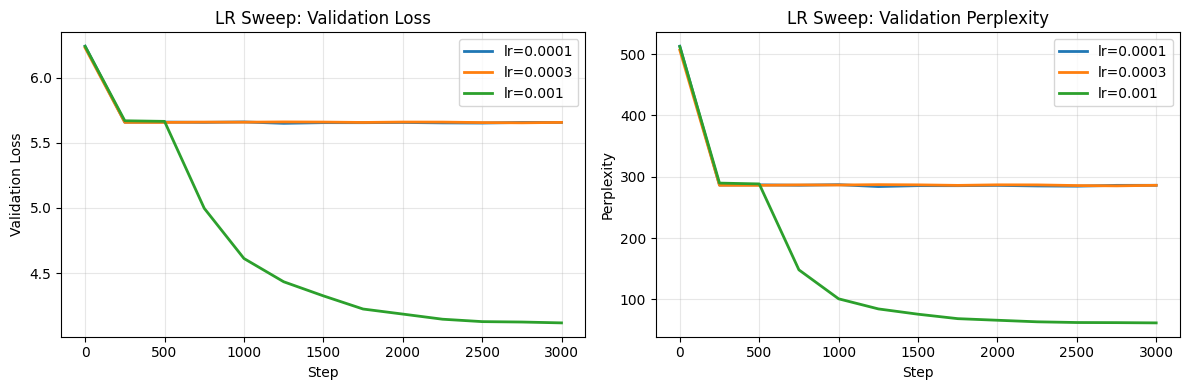


        LR  Final PPL   Time (s)
--------------------------------
     1e-04     285.99      101.7
     3e-04     286.00       97.1
     1e-03      61.50      101.4

Saved: figures/lr_sweep.png


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for lr_val, res in lr_results.items():
    h = res["hist"]
    axes[0].plot(h["step"], h["val_loss"], label=f"lr={lr_val}", linewidth=2)
    axes[1].plot(h["step"], h["val_ppl"], label=f"lr={lr_val}", linewidth=2)

axes[0].set_xlabel("Step"); axes[0].set_ylabel("Validation Loss")
axes[0].set_title("LR Sweep: Validation Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Step"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("LR Sweep: Validation Perplexity"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/lr_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary table
print(f"\n{'LR':>10} {'Final PPL':>10} {'Time (s)':>10}")
print("-" * 32)
for lr_val, res in lr_results.items():
    print(f"{lr_val:>10.0e} {res['hist']['val_ppl'][-1]:>10.2f} {res['time']:>10.1f}")
print("\nSaved: figures/lr_sweep.png")

### 5.2 Positional Encoding Ablation

We train the same architecture without positional encoding to test whether the model can learn position-dependent patterns from the causal mask alone.

In [59]:
class TinyTransformerNoPos(TinyTransformer):
    """Same architecture but with positional encoding removed."""
    def forward(self, x):
        x = self.token_emb(x)
        # Skip self.pos_enc(x) -- no positional information
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm_f(x)
        return self.lm_head(x)

print("Training WITHOUT positional encoding...")
model_no_pos = TinyTransformerNoPos(VOCAB_SIZE, D_MODEL, N_HEADS, N_LAYERS, D_FF, SEQ_LEN, DROPOUT).to(device)
hist_no_pos, time_no_pos = train_model(model_no_pos, label="no-pos")

print("\nTraining WITH positional encoding (baseline)...")
model_with_pos = TinyTransformer(VOCAB_SIZE, D_MODEL, N_HEADS, N_LAYERS, D_FF, SEQ_LEN, DROPOUT).to(device)
hist_with_pos, time_with_pos = train_model(model_with_pos, label="with-pos")

Training WITHOUT positional encoding...
  [no-pos] Step     0 | val_loss=6.2435 | ppl=514.65
  [no-pos] Step   250 | val_loss=4.6994 | ppl=109.89
  [no-pos] Step   500 | val_loss=4.3228 | ppl=75.40
  [no-pos] Step   750 | val_loss=4.2117 | ppl=67.47
  [no-pos] Step  1000 | val_loss=4.1452 | ppl=63.13
  [no-pos] Step  1250 | val_loss=4.1250 | ppl=61.87
  [no-pos] Step  1500 | val_loss=4.0956 | ppl=60.07
  [no-pos] Step  1750 | val_loss=4.0798 | ppl=59.14
  [no-pos] Step  2000 | val_loss=4.0711 | ppl=58.62
  [no-pos] Step  2250 | val_loss=4.0425 | ppl=56.97
  [no-pos] Step  2500 | val_loss=4.0462 | ppl=57.18
  [no-pos] Step  2750 | val_loss=4.0351 | ppl=56.55
  [no-pos] Step  2999 | val_loss=4.0396 | ppl=56.80
  [no-pos] Done in 101.3s | Final ppl=56.80

Training WITH positional encoding (baseline)...
  [with-pos] Step     0 | val_loss=6.2342 | ppl=509.88
  [with-pos] Step   250 | val_loss=5.6568 | ppl=286.24
  [with-pos] Step   500 | val_loss=5.6542 | ppl=285.49
  [with-pos] Step   750 

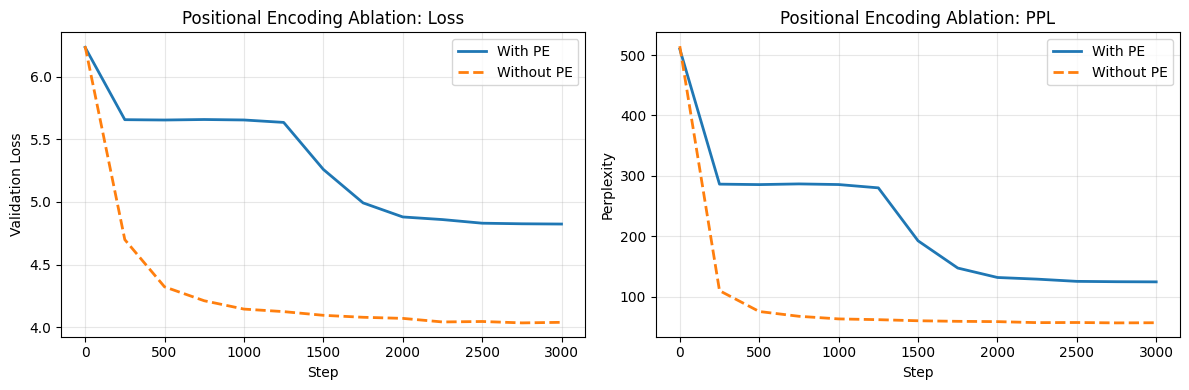


With PE:    final ppl=124.45
Without PE: final ppl=56.80

With PE:    ROMEO: My cres to fnd: I have heny, To hafenes' geas, To prs your sters, And I wist have I be the mrit, my reck, Bether me, And he the c
Without PE: ROMEO: Ay, good good work; that will to his keeps, I know to' t the tis garm! GIt; And now thou food, wounter' s in' ll you to be not for this fanus! 

Saved: figures/pos_encoding_ablation.png


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_with_pos["step"], hist_with_pos["val_loss"], label="With PE", linewidth=2)
axes[0].plot(hist_no_pos["step"], hist_no_pos["val_loss"], label="Without PE", linewidth=2, linestyle="--")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Validation Loss")
axes[0].set_title("Positional Encoding Ablation: Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_with_pos["step"], hist_with_pos["val_ppl"], label="With PE", linewidth=2)
axes[1].plot(hist_no_pos["step"], hist_no_pos["val_ppl"], label="Without PE", linewidth=2, linestyle="--")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("Positional Encoding Ablation: PPL"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/pos_encoding_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nWith PE:    final ppl={hist_with_pos['val_ppl'][-1]:.2f}")
print(f"Without PE: final ppl={hist_no_pos['val_ppl'][-1]:.2f}")

# Compare generations
model_no_pos.eval()
model_with_pos.eval()
prompt = "ROMEO:"
inp = torch.tensor([tokenizer.encode(prompt).ids], dtype=torch.long, device=device)

gen_with = decode_tokens(model_with_pos.generate(inp, max_new_tokens=60, temperature=0.8, top_k=40)[0].cpu().tolist())
gen_without = decode_tokens(model_no_pos.generate(inp, max_new_tokens=60, temperature=0.8, top_k=40)[0].cpu().tolist())
print(f"\nWith PE:    {gen_with[:150]}")
print(f"Without PE: {gen_without[:150]}")
print("\nSaved: figures/pos_encoding_ablation.png")

### 5.3 Model Scale Comparison

We compare different model sizes to understand the capacity-performance trade-off.

In [61]:
scale_configs = [
    {"name": "Small (d=64, L=1)",  "d_model": 64,  "n_layers": 1, "d_ff": 256},
    {"name": "Base (d=128, L=2)",  "d_model": 128, "n_layers": 2, "d_ff": 512},
    {"name": "Large (d=192, L=3)", "d_model": 192, "n_layers": 3, "d_ff": 768},
]
scale_results = {}

for cfg in scale_configs:
    print(f"\nTraining {cfg['name']}...")
    m = TinyTransformer(VOCAB_SIZE, cfg["d_model"], N_HEADS, cfg["n_layers"], cfg["d_ff"], SEQ_LEN, DROPOUT).to(device)
    n_p = sum(p.numel() for p in m.parameters())
    print(f"  Parameters: {n_p:,}")
    h, t = train_model(m, label=cfg["name"])
    scale_results[cfg["name"]] = {"hist": h, "time": t, "params": n_p}
    del m
    torch.mps.empty_cache() if device.type == "mps" else None


Training Small (d=64, L=1)...
  Parameters: 82,420
  [Small (d=64, L=1)] Step     0 | val_loss=6.2504 | ppl=518.21
  [Small (d=64, L=1)] Step   250 | val_loss=5.6547 | ppl=285.64
  [Small (d=64, L=1)] Step   500 | val_loss=5.6571 | ppl=286.33
  [Small (d=64, L=1)] Step   750 | val_loss=5.6551 | ppl=285.75
  [Small (d=64, L=1)] Step  1000 | val_loss=5.6597 | ppl=287.06
  [Small (d=64, L=1)] Step  1250 | val_loss=5.6538 | ppl=285.37
  [Small (d=64, L=1)] Step  1500 | val_loss=5.6567 | ppl=286.19
  [Small (d=64, L=1)] Step  1750 | val_loss=5.6543 | ppl=285.51
  [Small (d=64, L=1)] Step  2000 | val_loss=5.6589 | ppl=286.85
  [Small (d=64, L=1)] Step  2250 | val_loss=5.6550 | ppl=285.70
  [Small (d=64, L=1)] Step  2500 | val_loss=5.6565 | ppl=286.16
  [Small (d=64, L=1)] Step  2750 | val_loss=5.6538 | ppl=285.39
  [Small (d=64, L=1)] Step  2999 | val_loss=5.6571 | ppl=286.30
  [Small (d=64, L=1)] Done in 32.8s | Final ppl=286.30

Training Base (d=128, L=2)...
  Parameters: 460,660
  [Base 

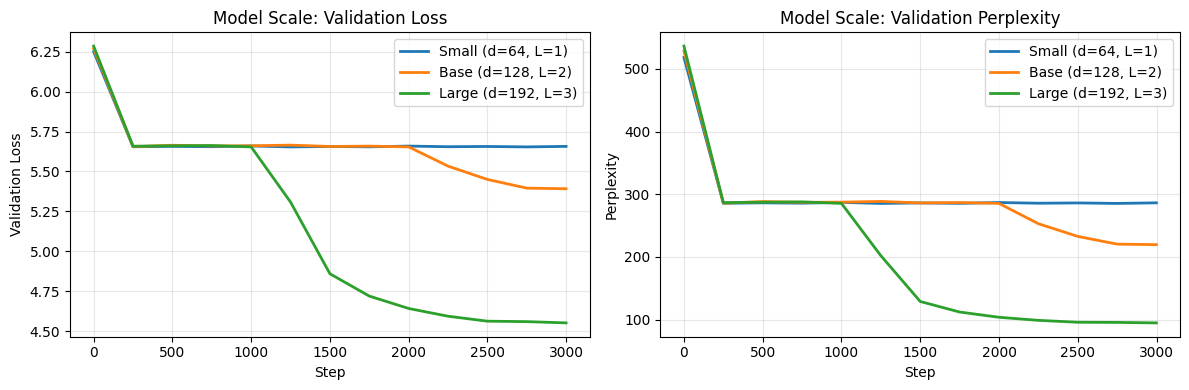


Config                        Params  Final PPL   Time (s)
---------------------------------------------------------
Small (d=64, L=1)             82,420     286.30       32.8
Base (d=128, L=2)            460,660     219.60       92.3
Large (d=192, L=3)         1,430,132      94.82      208.0

Saved: figures/model_scale.png


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, res in scale_results.items():
    h = res["hist"]
    axes[0].plot(h["step"], h["val_loss"], label=name, linewidth=2)
    axes[1].plot(h["step"], h["val_ppl"], label=name, linewidth=2)

axes[0].set_xlabel("Step"); axes[0].set_ylabel("Validation Loss")
axes[0].set_title("Model Scale: Validation Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Step"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("Model Scale: Validation Perplexity"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/model_scale.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'Config':<25} {'Params':>10} {'Final PPL':>10} {'Time (s)':>10}")
print("-" * 57)
for name, res in scale_results.items():
    print(f"{name:<25} {res['params']:>10,} {res['hist']['val_ppl'][-1]:>10.2f} {res['time']:>10.1f}")
print("\nSaved: figures/model_scale.png")

### 5.4 Context Length (Sequence Length) Ablation

We test how the context window size affects model performance, comparing three sequence lengths.

In [63]:
seq_configs = [32, 64, 128]
seq_results = {}

for sl in seq_configs:
    print(f"\nTraining with seq_len={sl}...")

    # Need to rebuild data batches for different seq lengths
    def get_batch_sl(split, seq_len=sl):
        d = train_data if split == "train" else val_data
        ix = torch.randint(len(d) - seq_len, (BATCH_SIZE,))
        x = torch.stack([d[i : i + seq_len] for i in ix])
        y = torch.stack([d[i+1 : i + seq_len + 1] for i in ix])
        return x.to(device), y.to(device)

    # Temporarily override get_batch
    _orig_get_batch = globals()["get_batch"]
    globals()["get_batch"] = get_batch_sl

    m = TinyTransformer(VOCAB_SIZE, D_MODEL, N_HEADS, N_LAYERS, D_FF, sl, DROPOUT).to(device)
    n_p = sum(p.numel() for p in m.parameters())
    print(f"  Parameters: {n_p:,}, Seq length: {sl}")
    h, t = train_model(m, label=f"seq={sl}")
    seq_results[sl] = {"hist": h, "time": t, "params": n_p}
    del m
    torch.mps.empty_cache() if device.type == "mps" else None

    # Restore
    globals()["get_batch"] = _orig_get_batch


Training with seq_len=32...
  Parameters: 460,660, Seq length: 32
  [seq=32] Step     0 | val_loss=6.2562 | ppl=521.21
  [seq=32] Step   250 | val_loss=5.6562 | ppl=286.07
  [seq=32] Step   500 | val_loss=5.6619 | ppl=287.69
  [seq=32] Step   750 | val_loss=5.6616 | ppl=287.60
  [seq=32] Step  1000 | val_loss=5.6601 | ppl=287.19
  [seq=32] Step  1250 | val_loss=5.6585 | ppl=286.71
  [seq=32] Step  1500 | val_loss=5.6549 | ppl=285.68
  [seq=32] Step  1750 | val_loss=5.6528 | ppl=285.08
  [seq=32] Step  2000 | val_loss=5.6564 | ppl=286.11
  [seq=32] Step  2250 | val_loss=5.6533 | ppl=285.24
  [seq=32] Step  2500 | val_loss=5.6540 | ppl=285.44
  [seq=32] Step  2750 | val_loss=5.6263 | ppl=277.64
  [seq=32] Step  2999 | val_loss=5.6198 | ppl=275.83
  [seq=32] Done in 48.9s | Final ppl=275.83

Training with seq_len=64...
  Parameters: 460,660, Seq length: 64
  [seq=64] Step     0 | val_loss=6.2236 | ppl=504.51
  [seq=64] Step   250 | val_loss=5.6592 | ppl=286.93
  [seq=64] Step   500 | val

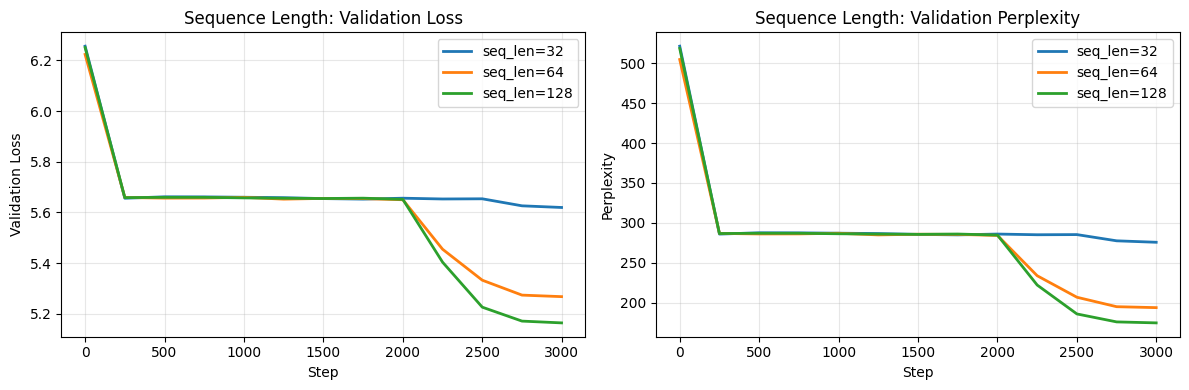


   Seq Len  Final PPL   Time (s)
--------------------------------
        32     275.83       48.9
        64     194.04      100.1
       128     174.95      208.9

Saved: figures/seq_length.png


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for sl, res in seq_results.items():
    h = res["hist"]
    axes[0].plot(h["step"], h["val_loss"], label=f"seq_len={sl}", linewidth=2)
    axes[1].plot(h["step"], h["val_ppl"], label=f"seq_len={sl}", linewidth=2)

axes[0].set_xlabel("Step"); axes[0].set_ylabel("Validation Loss")
axes[0].set_title("Sequence Length: Validation Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("Sequence Length: Validation Perplexity"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/seq_length.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'Seq Len':>10} {'Final PPL':>10} {'Time (s)':>10}")
print("-" * 32)
for sl, res in seq_results.items():
    print(f"{sl:>10} {res['hist']['val_ppl'][-1]:>10.2f} {res['time']:>10.1f}")
print("\nSaved: figures/seq_length.png")

### 5.5 Runtime & Memory Profile

In [65]:
# Profile forward and backward pass
model.eval()
xb, yb = get_batch("train")

# Forward pass timing
torch.mps.synchronize() if device.type == "mps" else None
t0 = time.time()
for _ in range(100):
    with torch.no_grad():
        _ = model(xb)
torch.mps.synchronize() if device.type == "mps" else None
fwd_time = (time.time() - t0) / 100

# Backward pass timing
model.train()
torch.mps.synchronize() if device.type == "mps" else None
t0 = time.time()
for _ in range(100):
    logits = model(xb)
    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), yb.view(-1))
    loss.backward()
    model.zero_grad(set_to_none=True)
torch.mps.synchronize() if device.type == "mps" else None
bwd_time = (time.time() - t0) / 100

n_params = sum(p.numel() for p in model.parameters())
param_mem = n_params * 4 / 1024**2  # float32

print("Runtime & Memory Profile")
print("=" * 40)
print(f"Parameters:       {n_params:,}")
print(f"Parameter memory: {param_mem:.2f} MB (float32)")
print(f"Forward pass:     {fwd_time*1000:.2f} ms")
print(f"Fwd + Backward:   {bwd_time*1000:.2f} ms")
print(f"Seq length:       {SEQ_LEN}")
print(f"Batch size:       {BATCH_SIZE}")
print(f"\nBottleneck: Self-attention is O(T^2 * d) in sequence length.")
print(f"  At T={SEQ_LEN}, attention matrix is {SEQ_LEN}x{SEQ_LEN} = {SEQ_LEN**2:,} entries per head.")

Runtime & Memory Profile
Parameters:       460,660
Parameter memory: 1.76 MB (float32)
Forward pass:     7.97 ms
Fwd + Backward:   29.95 ms
Seq length:       64
Batch size:       64

Bottleneck: Self-attention is O(T^2 * d) in sequence length.
  At T=64, attention matrix is 64x64 = 4,096 entries per head.
